In [ ]:
pip install opencv-python matplotlib seaborn scikit-image numpy

In [79]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('/content/002_080_001.jpg')  # Replace with your image path
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [80]:
# CLAHE (subtle enhancement)
clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

# Skip aggressive thresholding - use Bilateral filtering for preserving edges
filtered = cv2.bilateralFilter(enhanced, d=9, sigmaColor=75, sigmaSpace=75)

# Light sharpening
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(filtered, -1, sharpen_kernel)

# Final normalization
final_output = cv2.normalize(sharpened, None, 0, 255, cv2.NORM_MINMAX)
final_output = final_output.astype(np.uint8)


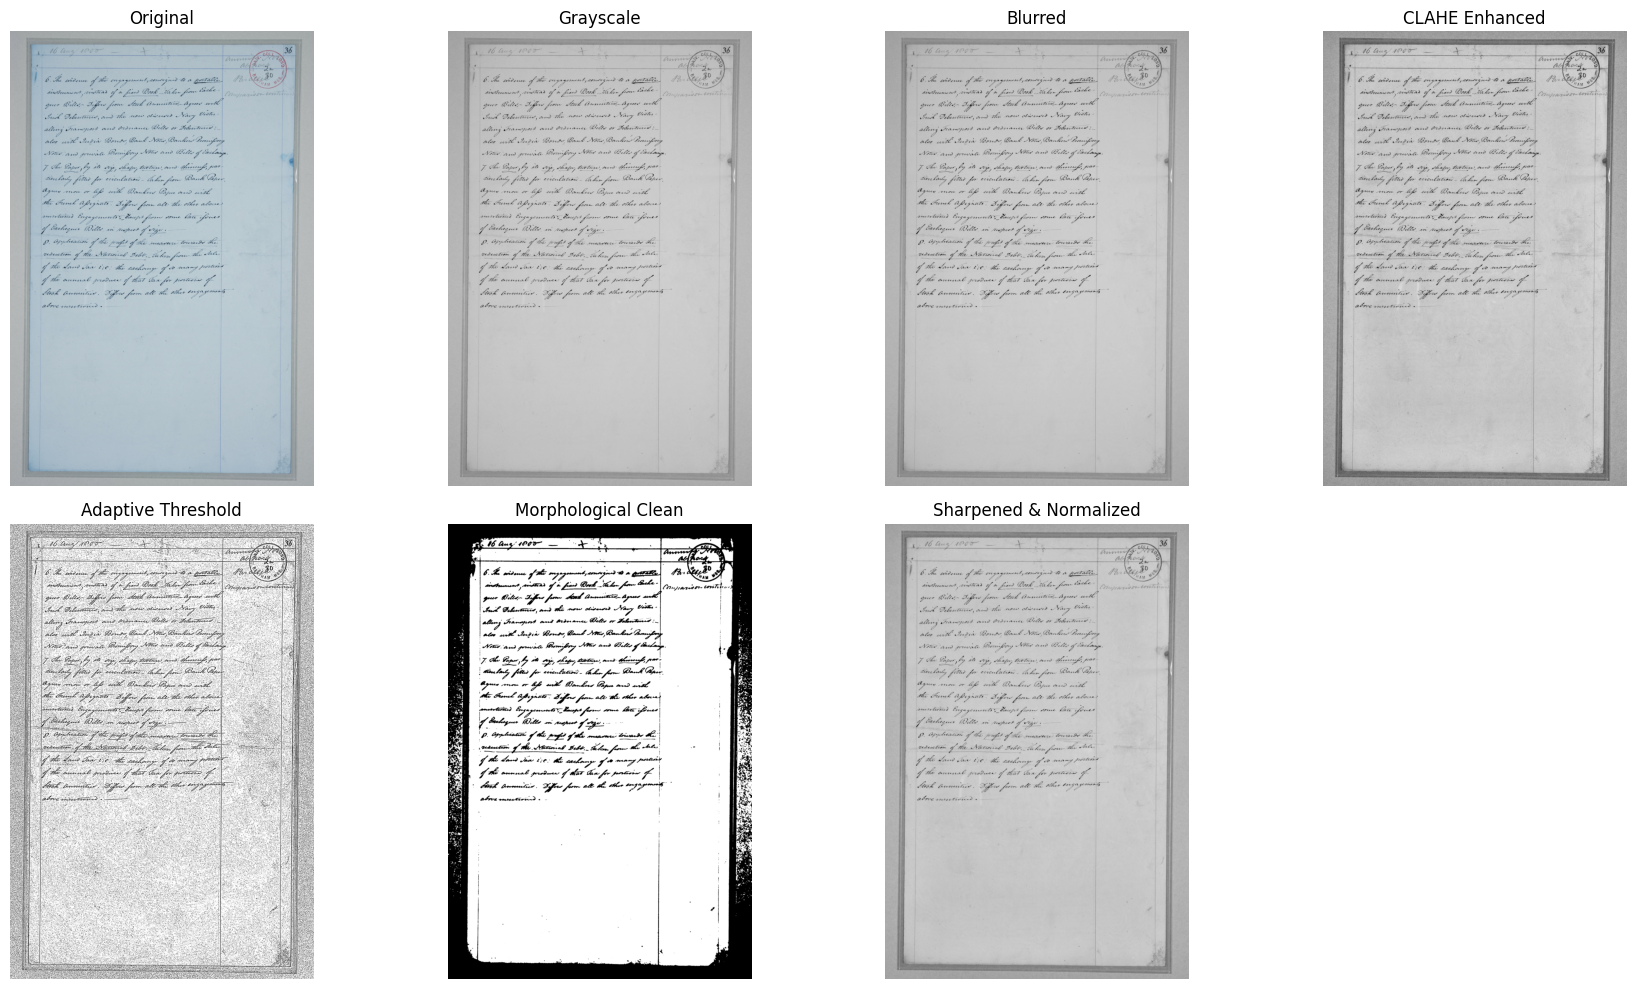


Final enhanced image saved at: enhanced_final_output.png


In [81]:
titles = [
    "Original", "Grayscale", "Blurred", "CLAHE Enhanced",
    "Adaptive Threshold", "Morphological Clean", "Sharpened & Normalized"
]
images = [image, gray, blurred, clahe_output, thresh, morphed, final_output]

# Plotting
plt.figure(figsize=(18, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Save final output
output_path = 'enhanced_final_output.png'
cv2.imwrite(output_path, final_output)
print(f"\nFinal enhanced image saved at: {output_path}")

<ipython-input-82-d4255f26be9b>:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256], color='blue')
<ipython-input-82-d4255f26be9b>:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(clahe_output.ravel(), 256, [0, 256], color='green')


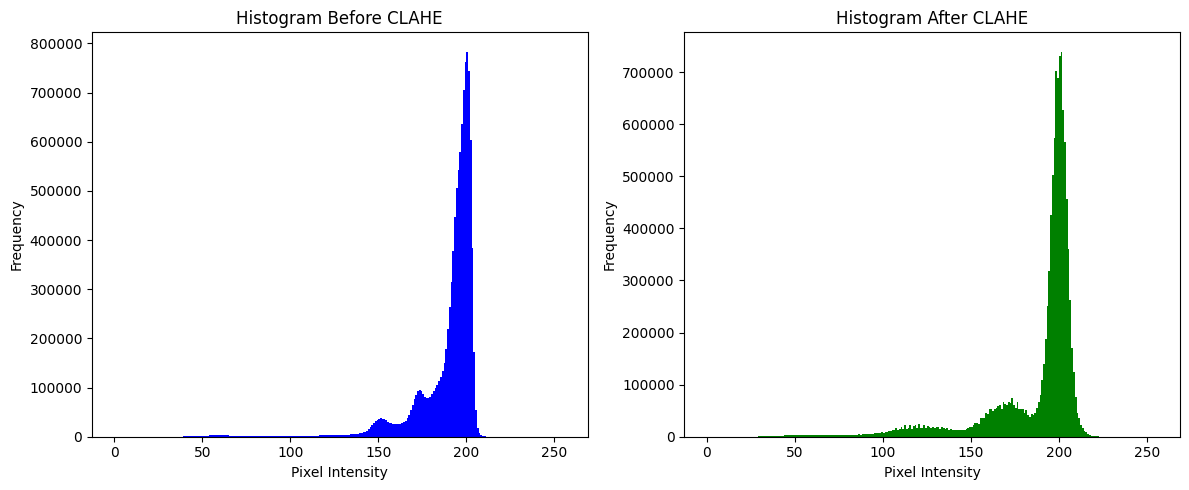

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("/content/002_080_001.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.hist(gray.ravel(), 256, [0, 256], color='blue')
plt.title('Histogram Before CLAHE')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')


plt.subplot(1, 2, 2)
plt.hist(clahe_output.ravel(), 256, [0, 256], color='green')
plt.title('Histogram After CLAHE')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


PSNR between Original and Enhanced: 33.06 dB


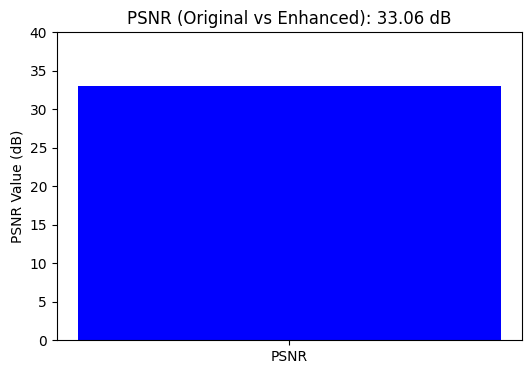

In [83]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def calculate_psnr(original, enhanced):
    mse = np.mean((original - enhanced) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    psnr = 20 * math.log10(PIXEL_MAX / math.sqrt(mse))
    return psnr
image = cv2.imread('/content/002_080_001.jpg')
gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
final_output = cv2.imread('/content/enhanced_final_output.png', cv2.IMREAD_GRAYSCALE)  # Example

gray_original = gray_original.astype(np.uint8)
enhanced_uint8 = final_output.astype(np.uint8)


psnr_value = calculate_psnr(gray_original, enhanced_uint8)


print(f"PSNR between Original and Enhanced: {psnr_value:.2f} dB")
plt.figure(figsize=(6, 4))
plt.bar(['PSNR'], [psnr_value], color='blue')
plt.title(f'PSNR (Original vs Enhanced): {psnr_value:.2f} dB')
plt.ylabel('PSNR Value (dB)')
plt.ylim(0, 40)
plt.show()


📊 SSIM (Original vs Enhanced): 0.9113


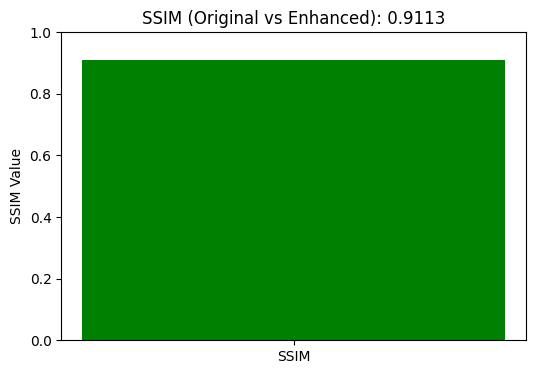

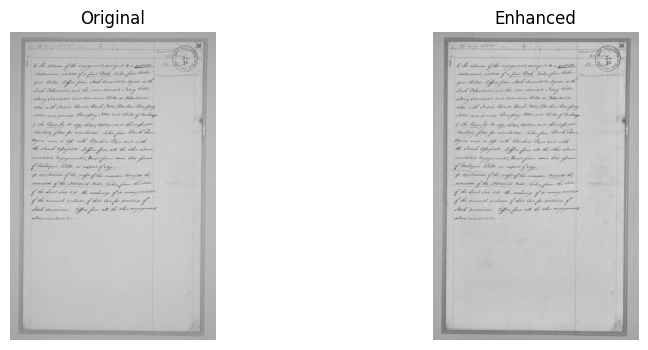

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

image = cv2.imread('/content/002_080_001.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
final_output = cv2.imread('/content/enhanced_final_output.png', cv2.IMREAD_GRAYSCALE)

ssim_val = ssim(gray, final_output)
print(f"📊 SSIM (Original vs Enhanced): {ssim_val:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['SSIM'], [ssim_val], color='green')
plt.title(f'SSIM (Original vs Enhanced): {ssim_val:.4f}')
plt.ylabel('SSIM Value')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(final_output, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.show()




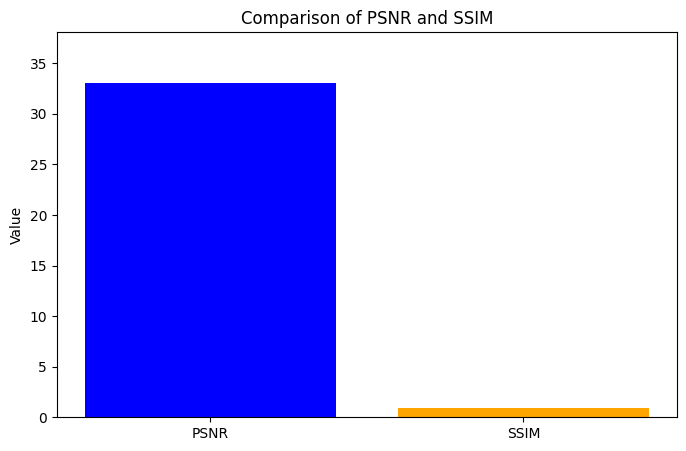

 PSNR between Original and Enhanced: 33.06 dB
SSIM (Original vs Enhanced): 0.9113


In [70]:
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.metrics import structural_similarity as ssim
import cv2


def calculate_psnr(original, enhanced):
    mse = np.mean((original - enhanced) ** 2)
    if mse == 0:
        return float('inf')  # Perfect match
    PIXEL_MAX = 255.0
    psnr = 20 * math.log10(PIXEL_MAX / math.sqrt(mse))
    return psnr
image = cv2.imread('/content/002_080_001.jpg')
final_output = cv2.imread('/content/enhanced_final_output.png')

# Convert to grayscale
gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_enhanced = cv2.cvtColor(final_output, cv2.COLOR_BGR2GRAY)

# Calculate PSNR
psnr_value = calculate_psnr(gray_original, gray_enhanced)

# Calculate SSIM
ssim_value, _ = ssim(gray_original, gray_enhanced, full=True)

metrics = ['PSNR', 'SSIM']
values = [psnr_value, ssim_value]


plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange'])


plt.title('Comparison of PSNR and SSIM')
plt.ylabel('Value')
plt.ylim([0, max(values) + 5])  # Adjust the y-axis limit if needed

plt.show()

# Print the values
print(f" PSNR between Original and Enhanced: {psnr_value:.2f} dB")
print(f"SSIM (Original vs Enhanced): {ssim_value:.4f}")


Entropy (Original Image): 5.2993
Entropy (Enhanced Image): 5.4010


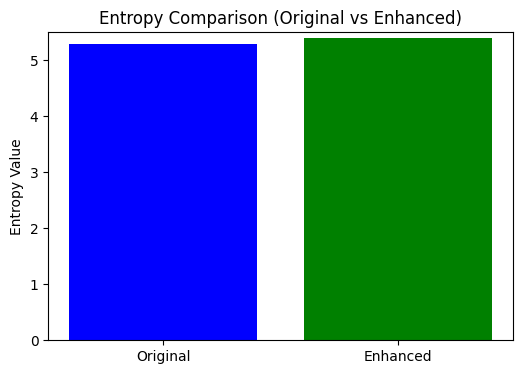

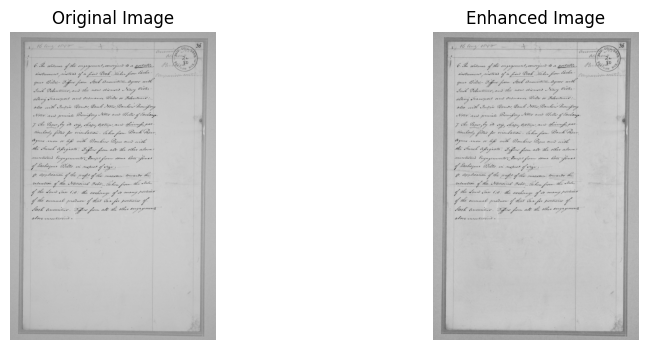

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy

# Load original image and convert to grayscale
image = cv2.imread('/content/002_080_001.jpg')  # Replace with your image path
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Example: Assuming `final_output` is the enhanced image from your processing pipeline
final_output = cv2.imread('/content/enhanced_final_output.png', cv2.IMREAD_GRAYSCALE)  # Replace with your image path

# Calculate entropy using skimage's shannon_entropy function
entropy_original = shannon_entropy(gray)
entropy_enhanced = shannon_entropy(final_output)

print(f"Entropy (Original Image): {entropy_original:.4f}")
print(f"Entropy (Enhanced Image): {entropy_enhanced:.4f}")

# Visualizing the entropy values in a bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Original', 'Enhanced'], [entropy_original, entropy_enhanced], color=['blue', 'green'])
plt.title('Entropy Comparison (Original vs Enhanced)')
plt.ylabel('Entropy Value')
plt.ylim(0, max(entropy_original, entropy_enhanced) + 0.1)  # Adjust the limit
plt.show()

# Show images side by side for visual comparison
plt.figure(figsize=(10, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Enhanced image
plt.subplot(1, 2, 2)
plt.imshow(final_output, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')

plt.show()


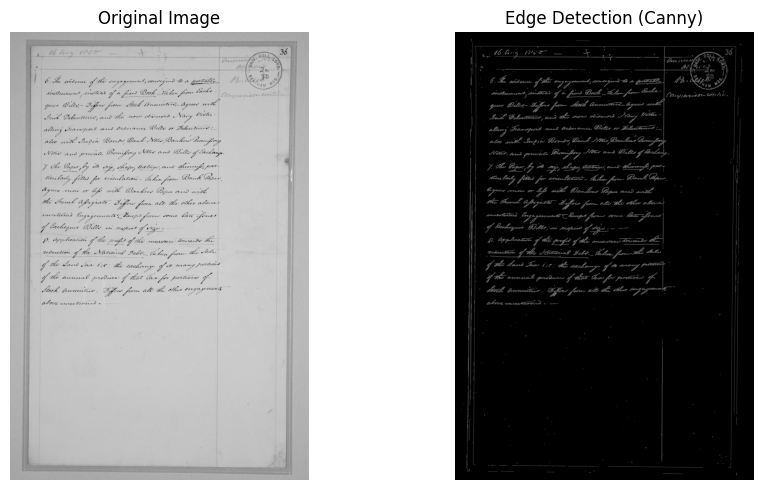

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the original image
image = cv2.imread('/content/002_080_001.jpg')  # Replace with your image path

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Canny Edge Detection
edges = cv2.Canny(gray, 100, 200)  # Lower and Upper threshold values can be adjusted

# Plot original and edge-detected images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Edge Detected Image
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()


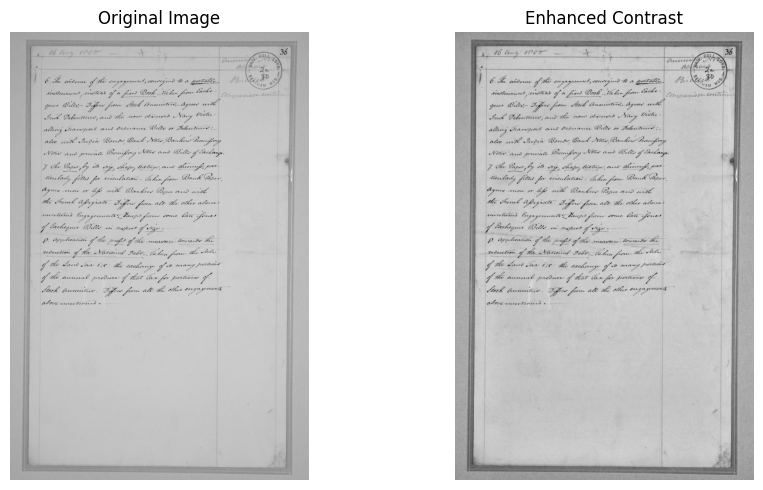

True

In [78]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
image = cv2.imread('/content/002_080_001.jpg', cv2.IMREAD_GRAYSCALE)

# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # You can tune clipLimit and tileGridSize
enhanced_image = clahe.apply(image)

# Visualize Original and Enhanced Images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title("Enhanced Contrast")
plt.axis('off')

plt.tight_layout()
plt.show()

# Save the enhanced image (optional)
cv2.imwrite('/content/enhanced_contrast_output.jpg', enhanced_image)


In [75]:
import cv2
import numpy as np

def calculate_cii(original, enhanced):
    # Convert to grayscale if not already
    if original is not None and len(original.shape) == 3:
        original = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    if enhanced is not None and len(enhanced.shape) == 3:
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)

    # Handle case where either image is None
    if original is None or enhanced is None:
        print("Error: One or both images could not be loaded.")
        return np.nan, np.nan, np.nan  # Return NaN for invalid results

    # Compute contrast as standard deviation of pixel intensities
    contrast_original = np.std(original)
    contrast_enhanced = np.std(enhanced)

    # Compute Contrast Improvement Index (CII)
    cii = (contrast_enhanced - contrast_original) / contrast_original
    return cii, contrast_original, contrast_enhanced

# Load original and enhanced images
original = cv2.imread('/content/002_080_001.jpg')
enhanced = cv2.imread('/content/enhanced_final_output.png') # Make sure enhanced_contrast_color.jpg file exists

# Check if enhanced image loaded correctly
if enhanced is None:
    print("Error: Could not load the enhanced image. Please check the path.")
else:
    # Calculate CII
    cii, c_orig, c_enh = calculate_cii(original, enhanced)

    # Display results
    print(f" Original Contrast: {c_orig:.4f}")
    print(f" Enhanced Contrast: {c_enh:.4f}")
    print(f" Contrast Improvement Index (CII): {cii:.4f}")

 Original Contrast: 19.3183
 Enhanced Contrast: 24.5824
 Contrast Improvement Index (CII): 0.2725


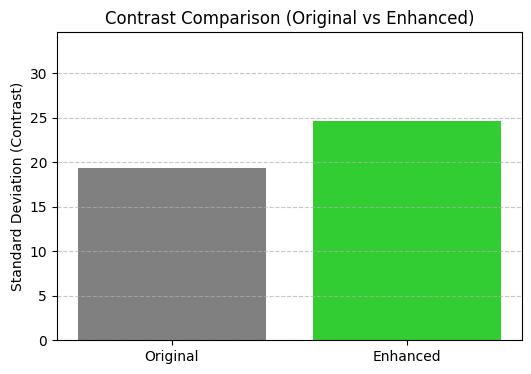

In [76]:
import matplotlib.pyplot as plt

# Bar chart to visualize contrast before and after
plt.figure(figsize=(6, 4))
plt.bar(['Original', 'Enhanced'], [c_orig, c_enh], color=['gray', 'limegreen'])
plt.title('Contrast Comparison (Original vs Enhanced)')
plt.ylabel('Standard Deviation (Contrast)')
plt.ylim(0, max(c_orig, c_enh) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
